# 05 Bagged decision tree
Reproduces paper section 5.3: BaggingClassifier over decision trees, sweeping num_trees.
Reference: valid weighted P/R/F1 at 100 trees = 0.452 / 0.476 / 0.456 (author's notebook).

In [1]:
!rm -f /content/evaluate.py
!rm -rf /content/funko-ml
!git clone https://github.com/rosa36-x/funko-ml.git
%cd /content/funko-ml/notebooks
!ls ../data ../src

Cloning into 'funko-ml'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 47 (delta 20), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 68.94 KiB | 13.79 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/funko-ml/notebooks
../data:
data_curated.csv  folds.pkl  processed.npz  processed_table.csv

../src:
evaluate.py  __init__.py


In [2]:
import sys; sys.path.append('../src')
import evaluate; print(evaluate.__file__)

/content/funko-ml/notebooks/../src/evaluate.py


In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from evaluate import load_data, evaluate_model, to_row, save_results

In [4]:
d, folds = load_data()
X, y = d['X_onehot'], d['y']
print(X.shape, np.bincount(y)[1:], len(folds))

(359, 59) [146 153  46  10   4] 4


In [5]:
NUM_TREES = [2, 5, 10, 20, 50, 100, 200]
rows = []
for n in NUM_TREES:
    res = evaluate_model(
        lambda: BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n, random_state=1),
        X, y, folds)
    rows.append(to_row('bagged_dt', res, num_trees=n))
df = pd.DataFrame(rows)
df[['num_trees', 'train_precision', 'train_recall', 'train_f1', 'valid_precision', 'valid_recall', 'valid_f1']]

,num_trees,train_precision,train_recall,train_f1,valid_precision,valid_recall,valid_f1
0,2,0.7932,0.7688,0.7588,0.4063,0.4624,0.4195
1,5,0.9151,0.9136,0.9131,0.4280,0.4541,0.4357
2,10,0.9458,0.9443,0.9440,0.4646,0.4736,0.4526
3,20,0.9817,0.9814,0.9814,0.4610,0.4680,0.4476
4,50,0.9836,0.9833,0.9833,0.4502,0.4765,0.4541
5,100,0.9837,0.9833,0.9833,0.4522,0.4764,0.4557
6,200,0.9836,0.9833,0.9833,0.4235,0.4486,0.4276


In [6]:
df[['num_trees'] + [f'valid_bin{i}_precision' for i in range(1, 6)]]

,num_trees,valid_bin1_precision,valid_bin2_precision,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision
0,2,0.4815,0.4667,0.0917,0.0,0.00
1,5,0.4806,0.4660,0.2381,0.0,0.25
2,10,0.5124,0.4881,0.3690,0.0,0.00
3,20,0.5015,0.4820,0.3940,0.0,0.00
4,50,0.5192,0.4791,0.2693,0.0,0.00
5,100,0.5113,0.4821,0.3006,0.0,0.00
6,200,0.4879,0.4581,0.2277,0.0,0.00


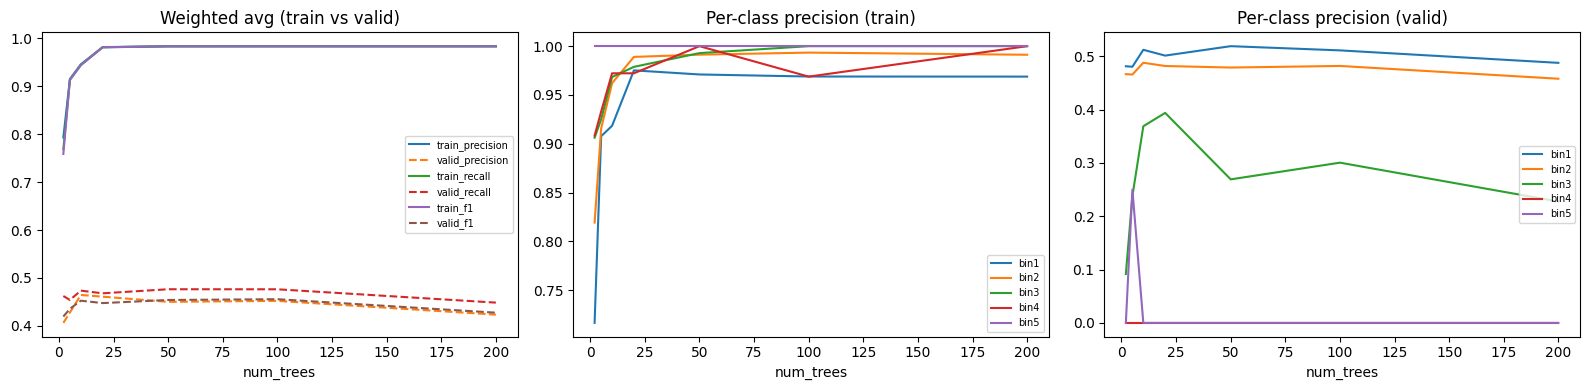

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for k in ['precision', 'recall', 'f1']:
    ax[0].plot(df['num_trees'], df[f'train_{k}'], label=f'train_{k}')
    ax[0].plot(df['num_trees'], df[f'valid_{k}'], '--', label=f'valid_{k}')
for i in range(1, 6):
    ax[1].plot(df['num_trees'], df[f'train_bin{i}_precision'], label=f'bin{i}')
    ax[2].plot(df['num_trees'], df[f'valid_bin{i}_precision'], label=f'bin{i}')
for a, t in zip(ax, ['Weighted avg (train vs valid)', 'Per-class precision (train)', 'Per-class precision (valid)']):
    a.set_title(t); a.set_xlabel('num_trees'); a.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../results/bagged_dt_curves.png', dpi=150)
plt.show()

In [8]:
best = df.loc[df['valid_f1'].idxmax()]
r100 = df[df['num_trees'] == 100].iloc[0]
print(f"best valid F1 at num_trees={int(best['num_trees'])}: {best['valid_f1']:.3f}")
print(f"100 trees  yours: {r100['valid_precision']:.3f} / {r100['valid_recall']:.3f} / {r100['valid_f1']:.3f}")
print("100 trees  reported (author's notebook): 0.452 / 0.476 / 0.456")

best valid F1 at num_trees=100: 0.456
100 trees  yours: 0.452 / 0.476 / 0.456
100 trees  reported (author's notebook): 0.452 / 0.476 / 0.456


In [9]:
save_results('bagged_dt', rows)

,model,num_trees,train_precision,train_recall,train_f1,train_bin1_precision,train_bin2_precision,train_bin3_precision,train_bin4_precision,train_bin5_precision,valid_precision,valid_recall,valid_f1,valid_bin1_precision,valid_bin2_precision,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision
0,bagged_dt,2,0.7932,0.7688,0.7588,0.7164,0.8192,0.9062,0.9083,1.0,0.4063,0.4624,0.4195,0.4815,0.4667,0.0917,0.0,0.00
1,bagged_dt,5,0.9151,0.9136,0.9131,0.9077,0.9156,0.9250,0.9330,1.0,0.4280,0.4541,0.4357,0.4806,0.4660,0.2381,0.0,0.25
2,bagged_dt,10,0.9458,0.9443,0.9440,0.9184,0.9621,0.9684,0.9722,1.0,0.4646,0.4736,0.4526,0.5124,0.4881,0.3690,0.0,0.00
3,bagged_dt,20,0.9817,0.9814,0.9814,0.9752,0.9890,0.9788,0.9722,1.0,0.4610,0.4680,0.4476,0.5015,0.4820,0.3940,0.0,0.00
4,bagged_dt,50,0.9836,0.9833,0.9833,0.9710,0.9913,0.9929,1.0000,1.0,0.4502,0.4765,0.4541,0.5192,0.4791,0.2693,0.0,0.00
5,bagged_dt,100,0.9837,0.9833,0.9833,0.9689,0.9934,1.0000,0.9688,1.0,0.4522,0.4764,0.4557,0.5113,0.4821,0.3006,0.0,0.00
6,bagged_dt,200,0.9836,0.9833,0.9833,0.9688,0.9912,1.0000,1.0000,1.0,0.4235,0.4486,0.4276,0.4879,0.4581,0.2277,0.0,0.00


In [10]:
from google.colab import files
files.download('../results/bagged_dt.csv')
files.download('../results/bagged_dt_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>